In [7]:
import pandas as pd
import xgboost
import shap
print("All good ✅")

All good ✅


Load Data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')

print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass distribution:\n", df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].value_counts()[1]/len(df)*100:.4f}%")

Task was destroyed but it is pending!
task: <Task pending name='Task-338' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/syedrauf/fraud_detection_project/venv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-339' coro=<Kernel.shell_main() running at /Users/syedrauf/fraud_detection_project/venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/syedrauf/fraud_detection_project/venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/syedrauf/fraud_detection_project/venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:2255: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return klass(values, ndim=2, placement=placement, refs=refs)
Task was destroyed but it is pending!
task: <Task pending name='Task-339' coro=<Kernel.shell_main() running at /Users/syedrauf/fraud_detection_project/venv/lib

Shape: (284807, 31)

Missing values: 0

Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


Class Distribution

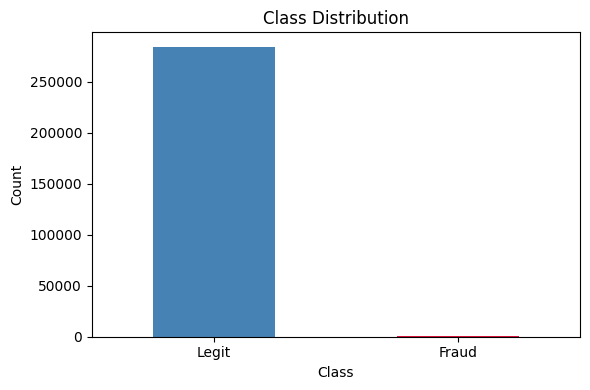

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
df['Class'].value_counts().plot(kind='bar', color=['steelblue','crimson'], ax=ax)
ax.set_xticklabels(['Legit', 'Fraud'], rotation=0)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150)
plt.show()

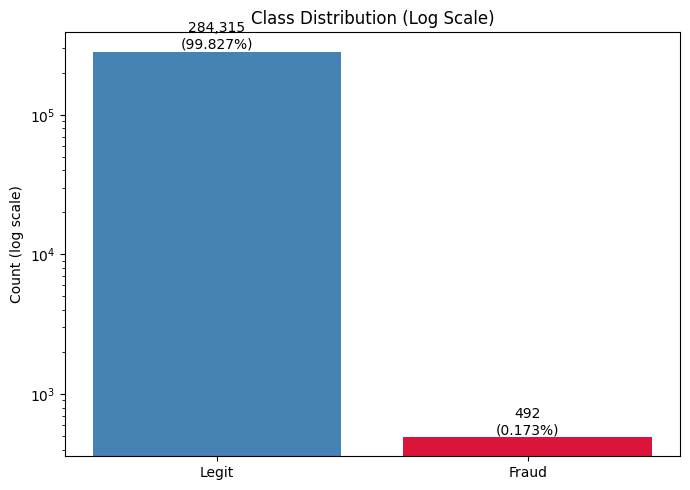

In [9]:
counts = df['Class'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ['Legit', 'Fraud'],
    counts.values,
    color=['steelblue', 'crimson']
)

ax.set_yscale('log')
ax.set_ylabel('Count (log scale)')
ax.set_title('Class Distribution (Log Scale)')

# Add count and percentage labels
total = counts.sum()

for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width()/2,
        count,
        f'{count:,}\n({pct:.3f}%)',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

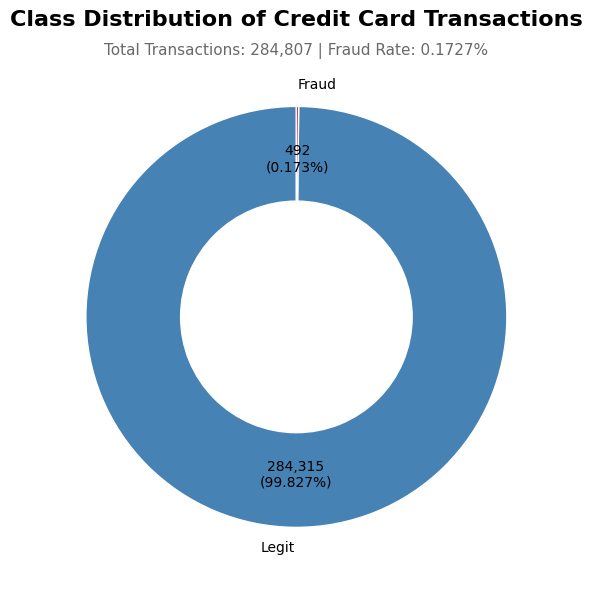

In [12]:
import matplotlib.pyplot as plt

counts = df['Class'].value_counts().sort_index()

labels = ['Legit', 'Fraud']
colors = ['steelblue', 'crimson']

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{count:,}\n({pct:.3f}%)'
    return my_format

fig, ax = plt.subplots(figsize=(8, 6))

wedges, texts, autotexts = ax.pie(
    counts,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct=autopct_format(counts),
    pctdistance=0.75,
    labeldistance=1.1,
    wedgeprops=dict(width=0.45, edgecolor='white')  # donut style
)

# Main title
ax.set_title(
    'Class Distribution of Credit Card Transactions',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Subtitle
fig.text(
    0.5,
    0.90,
    f'Total Transactions: {counts.sum():,} | Fraud Rate: {counts[1]/counts.sum()*100:.4f}%',
    ha='center',
    fontsize=11,
    color='dimgray'
)

plt.tight_layout()
plt.savefig('../outputs/class_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

Transaction Amount by Class

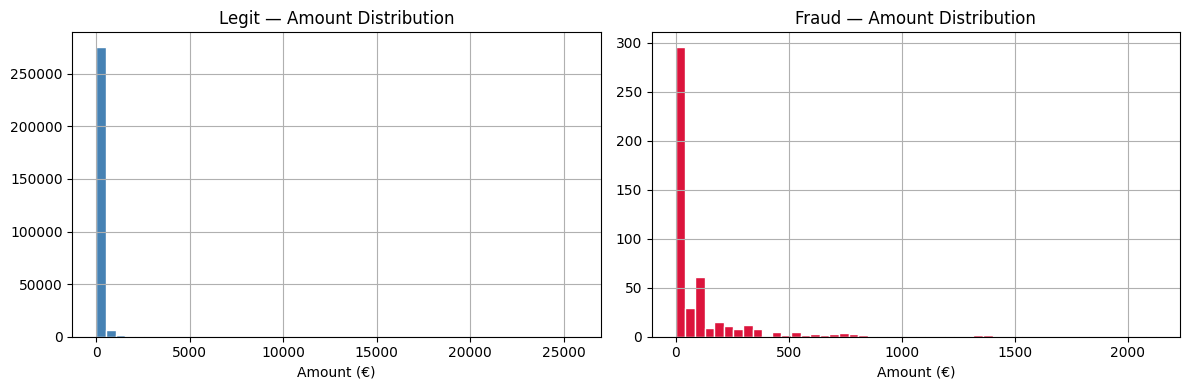


Fraud transaction stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df[df['Class']==0]['Amount'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Legit — Amount Distribution')
axes[0].set_xlabel('Amount (€)')

df[df['Class']==1]['Amount'].hist(bins=50, ax=axes[1], color='crimson', edgecolor='white')
axes[1].set_title('Fraud — Amount Distribution')
axes[1].set_xlabel('Amount (€)')

plt.tight_layout()
plt.savefig('../outputs/amount_distribution.png', dpi=150)
plt.show()

print("\nFraud transaction stats:")
print(df[df['Class']==1]['Amount'].describe())

Time Distribution

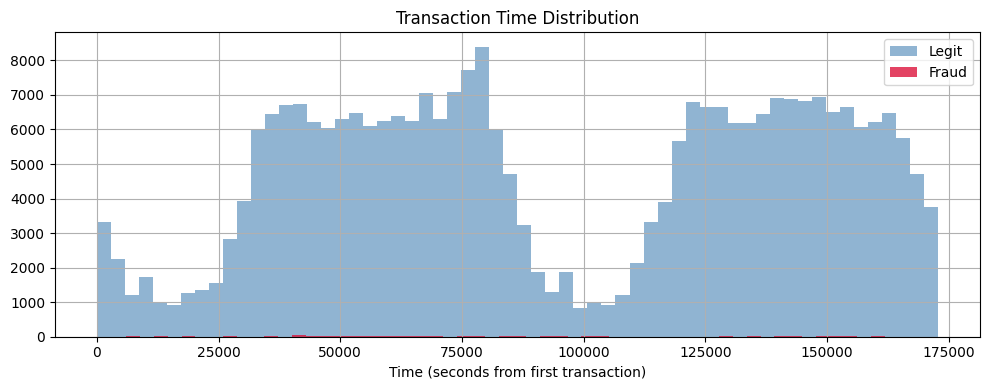

In [5]:
fig, ax = plt.subplots(figsize=(10,4))
df[df['Class']==0]['Time'].hist(bins=60, alpha=0.6, label='Legit', color='steelblue', ax=ax)
df[df['Class']==1]['Time'].hist(bins=60, alpha=0.8, label='Fraud', color='crimson', ax=ax)
ax.set_title('Transaction Time Distribution')
ax.set_xlabel('Time (seconds from first transaction)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/time_distribution.png', dpi=150)
plt.show()

Feature Correlation (top features with Class)


Top 10 features correlated with fraud:
 V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


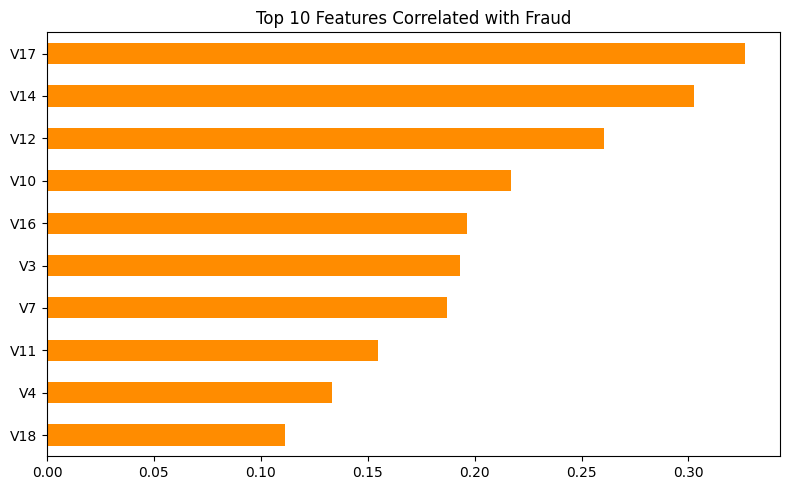

In [6]:
correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print("\nTop 10 features correlated with fraud:\n", correlations.head(10))

fig, ax = plt.subplots(figsize=(8,5))
correlations.head(10).plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 10 Features Correlated with Fraud')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/feature_correlation.png', dpi=150)
plt.show()